In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table  import  Table,Column
from astropy import units as u
import yaml
import warnings
warnings.filterwarnings("ignore", message="Warning: ")

In [3]:
def return_xy(group, flag=None):
    nufnu = group['nufnu'].data
    en = group['en'].data

    nufnu_err = [group['nufnu_elo'].data, group['nufnu_eup'].data]
    en_err = [group['en_wlo'].data, group['en_wup'].data]

    instrument  =  group['instrument'][0]
    target = group['srcname'][0]
    comment = group['comments'][0]

    if comment == "''" or comment == "" or not comment:
        comment = ""

    return en, nufnu, en_err, nufnu_err, instrument, target, comment


In [4]:
def plot(ecsvdata, group_by, subplot):
    target      = ecsvdata.meta['Source']
    description = ecsvdata.meta['Figure']
    filename    = ecsvdata.meta['Filename']
    title       = ecsvdata.meta['Title']
    comments    = ecsvdata.meta['Comments']
    reference   = ecsvdata.meta['Reference']
    print("Filename:", filename)
    print("Source:", target)
    print("Description:", description)
    print("Title:", title)
    print("Comments:", comments)
    print("Reference:", reference)
    print("-------------------------------")

    if not group_by:
        group_by = ["instrument"]

    data_grouped = ecsvdata.group_by(group_by)

    for group in data_grouped.groups:
        en, nufnu, en_err, nufnu_err, instrument, target, comment = return_xy(group)

        subplot.errorbar(x=en, y=nufnu,
                         xerr=en_err, yerr=nufnu_err,
                         marker = 'o',
                         linewidth=0, elinewidth=0.5,
                         label=instrument+' '+comment+' '+target)

    plt.setp(subplot, xlabel=ecsvdata['en'].unit)
    plt.setp(subplot, ylabel=ecsvdata['nufnu'].unit)

    subplot.loglog()
    subplot.grid()
    subplot.legend(loc='best')

dict_items([('magic_2025f_fig4_sed_FERMI.ecsv', ['instrument'])])
Filename: magic_2025f_fig4_sed_FERMI.ecsv
Source: B2-1811+31
Description: Fig. 4 High-energy gamma-ray spectral energy distribution evolution
Title: Very-high-energy gamma-ray detection and long-term multi-wavelength view of the flaring blazar B2 1811+31
Comments: Fermi-LAT spectrum in the pre-flare, flare and post-flare periods
Reference: magic_2025f.yaml
-------------------------------


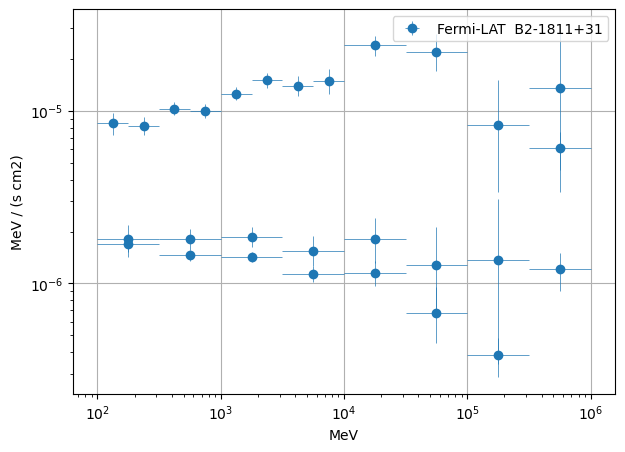

In [8]:
SEDs = {'magic_2025f_fig4_sed_FERMI.ecsv' : ["instrument"],  # group by columns like "instrument"
       # 'filename2.ecsv'  : ["columns", "to", "group", "by"]
       }

fig, axs = plt.subplots(len(SEDs), figsize=(7, len(SEDs)*5))

print(SEDs.items())

for i, SED_item in enumerate(SEDs.items()):
    filename, group_by = SED_item
    ecsvdata = Table.read(filename, format='ascii.ecsv', delimiter=';')
    plot(ecsvdata=ecsvdata, group_by=group_by, subplot=axs if len(SEDs) == 1 else axs[i])
